# Proyecto Final: Análisis Estadístico y Rendimiento en Tenis Profesional (ATP 2000-2019)
**Autor:** Raúl Salva Jimeno 
**Objetivo:** Integrar dos fuentes de datos independientes, realizar limpieza y tipado profundo, ejecutar un análisis exploratorio de datos (EDA) con pruebas estadísticas y preparar un conjunto procesado para un dashboard operativo.

## 1. Ingesta y Carga de Datos (Fuentes en Bruto)
Se cargan las dos fuentes requeridas:
* **Fuente A:** Histórico de partidos disputados entre 2000 y 2019 (múltiples archivos CSV anuales concatenados).
* **Fuente B:** Catálogo maestro de tenistas (`atp_players.csv`) con datos biográficos y demográficos.

In [1]:
import pandas as pd
import glob
import os

# 1. Cargar y concatenar todos los partidos (Fuente A)
ruta_partidos = '../data/raw/matches/atp_matches_*.csv'
archivos_partidos = sorted(glob.glob(ruta_partidos))

lista_df = [pd.read_csv(f) for f in archivos_partidos]
df_matches = pd.concat(lista_df, ignore_index=True)

print(f"Fuente A (Partidos): {df_matches.shape[0]} filas, {df_matches.shape[1]} columnas")

# 2. Cargar jugadores (Fuente B)
df_players = pd.read_csv('../data/raw/atp_players.csv')
print(f"Fuente B (Jugadores): {df_players.shape[0]} filas, {df_players.shape[1]} columnas")

Fuente A (Partidos): 59430 filas, 32 columnas
Fuente B (Jugadores): 54067 filas, 6 columnas


## 2. Fusión Relacional (Merge) y Validación de Requisitos
Se enriquece el conjunto de partidos cruzando por identificador de jugador (`winner_id` y `loser_id`) con la tabla maestra de jugadores para incorporar datos de mano hábil, país y fecha de nacimiento.  
Se valida el cumplimiento de las condiciones mínimas del proyecto (> 50.000 filas y > 20 columnas).

In [2]:
# Inspeccionar columnas y primeras filas de ambas tablas
print("Columnas de Partidos (Fuente A):")
print(df_matches.columns.tolist())

print("\nColumnas y muestra de Jugadores (Fuente B):")
display(df_players.head(3))

Columnas de Partidos (Fuente A):
['tourney_id', 'tourney_name', 'tourney_date', 'surface', 'winner_id', 'loser_id', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points']

Columnas y muestra de Jugadores (Fuente B):


,player_id,name_first,name_list,hand,birthdate,country
0,100001,Gardnar,Mulloy,R,19131122.0,USA
1,100002,Pancho,Segura,R,19210620.0,ECU
2,100003,Frank,Sedgman,R,19271002.0,AUS


## 3. Diagnóstico de Calidad de Datos
Evaluación de valores ausentes (*missing values*), consistencia de tipos y comprobación de duplicados exactos. Se detectan patrones de nulos en partidos no disputados o incompletos.

In [3]:
# 1. Preparar la tabla de jugadores para el cruce
# Creamos el nombre completo uniendo nombre y apellido
df_players['full_name'] = df_players['name_first'].fillna('') + ' ' + df_players['name_list'].fillna('')
df_players['full_name'] = df_players['full_name'].str.strip()

# Seleccionamos las columnas útiles para cruzar
players_info = df_players[['player_id', 'full_name', 'hand', 'birthdate', 'country']].copy()

# 2. Cruce con el Ganador (Winner)
df_merged = df_matches.merge(
    players_info,
    left_on='winner_id',
    right_on='player_id',
    how='left'
).rename(columns={
    'full_name': 'winner_name_full',
    'hand': 'winner_hand',
    'birthdate': 'winner_birthdate',
    'country': 'winner_country'
}).drop(columns=['player_id'])

# 3. Cruce con el Perdedor (Loser)
df_final = df_merged.merge(
    players_info,
    left_on='loser_id',
    right_on='player_id',
    how='left'
).rename(columns={
    'full_name': 'loser_name_full',
    'hand': 'loser_hand',
    'birthdate': 'loser_birthdate',
    'country': 'loser_country'
}).drop(columns=['player_id'])

# 4. Verificación de requisitos de entrega
filas, columnas = df_final.shape
print("=" * 45)
print("     VERIFICACIÓN DE REQUISITOS MÍNIMOS     ")
print("=" * 45)
print(f"Total de Filas:    {filas:,}  (Mínimo exigido: 50.000) -> {'CUMPLE' if filas >= 50000 else 'NO CUMPLE'}")
print(f"Total de Columnas: {columnas}      (Mínimo exigido: 20)     -> {'CUMPLE' if columnas >= 20 else 'NO CUMPLE'}")
print("=" * 45)

     VERIFICACIÓN DE REQUISITOS MÍNIMOS     
Total de Filas:    59,430  (Mínimo exigido: 50.000) -> CUMPLE
Total de Columnas: 40      (Mínimo exigido: 20)     -> CUMPLE


## 4. Limpieza Profunda y Feature Engineering
* Eliminación de registros con métricas de juego ausentes y outliers por retiradas tempranas (< 15 minutos).
* Cálculo dinámico de la edad exacta de los jugadores en la fecha de cada torneo.
* Generación de nuevas variables de rendimiento: efectividad de primer servicio (%), puntos ganados con primer saque (%) y tasa de conversión de break points salvados.
* Exportación del dataset procesado a `data/processed/atp_matches_clean.csv`.

In [4]:
# 1. Diagnóstico inicial de nulos y tipos
print("--- RESUMEN DE NULOS (Top 15 columnas con más valores vacíos) ---")
nulos = df_final.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False).head(15))

# 2. Comprobar duplicados
print(f"\nFilas duplicadas exactas: {df_final.duplicated().sum()}")

# 3. Conversión de fechas a tipo datetime
df_final['tourney_date'] = pd.to_datetime(df_final['tourney_date'].astype(str), format='%Y%m%d', errors='coerce')
df_final['winner_birthdate'] = pd.to_datetime(df_final['winner_birthdate'].astype(str).str.split('.').str[0], format='%Y%m%d', errors='coerce')
df_final['loser_birthdate'] = pd.to_datetime(df_final['loser_birthdate'].astype(str).str.split('.').str[0], format='%Y%m%d', errors='coerce')

# 4. Cálculo de edad exacta en la fecha del torneo (en años)
df_final['winner_age_calc'] = ((df_final['tourney_date'] - df_final['winner_birthdate']).dt.days // 365.25)
df_final['loser_age_calc'] = ((df_final['tourney_date'] - df_final['loser_birthdate']).dt.days // 365.25)

# 5. Normalizar variables categóricas (Mano y Superficie)
df_final['surface'] = df_final['surface'].str.strip().str.title()
df_final['winner_hand'] = df_final['winner_hand'].fillna('U').replace({'R': 'Right', 'L': 'Left', 'U': 'Unknown'})
df_final['loser_hand'] = df_final['loser_hand'].fillna('U').replace({'R': 'Right', 'L': 'Left', 'U': 'Unknown'})

print("\nFechas y variables categóricas procesadas correctamente.")
df_final[['tourney_name', 'tourney_date', 'surface', 'winner_name_full', 'winner_age_calc', 'winner_hand']].head(3)

--- RESUMEN DE NULOS (Top 15 columnas con más valores vacíos) ---
minutes      6999
w_df         5681
w_ace        5681
w_1stIn      5681
w_svpt       5681
w_SvGms      5681
w_bpSaved    5681
w_1stWon     5681
w_2ndWon     5681
w_bpFaced    5681
l_ace        5681
l_svpt       5681
l_df         5681
l_2ndWon     5681
l_SvGms      5681
dtype: int64

Filas duplicadas exactas: 0

Fechas y variables categóricas procesadas correctamente.


,tourney_name,tourney_date,surface,winner_name_full,winner_age_calc,winner_hand
0,Adelaide,2000-01-03,Hard,Thomas Enqvist,25.0,Right
1,Adelaide,2000-01-03,Hard,Roger Federer,18.0,Right
2,Adelaide,2000-01-03,Hard,Jan Michael Gambill,22.0,Right


## 5. Análisis Estadístico Descriptivo y Visualización (EDA)
En esta sección se evalúan las principales hipótesis deportivas sobre el conjunto final procesado (52.351 partidos):
1. **Métricas descriptivas centrales:** Duración media, número de aces y efectividad de servicio por superficie.
2. **Impacto biométrico:** Relación entre la altura del jugador y el volumen de aces logrados.
3. **Distribución temporal y por superficie:** Volumen de partidos según tipo de pista (Hard, Clay, Grass, Carpet).
4. **Matriz de correlación:** Dependencia lineal entre métricas técnicas de saque, resto y resultado.

In [6]:
import os

# 1. Filtrar registros incompletos para asegurar calidad de datos en estadísticas
df_clean = df_final.dropna(subset=['w_ace', 'l_ace', 'minutes']).copy()

# Eliminar partidos con duraciones anómalas (outliers por retiro rápido < 15 min)
df_clean = df_clean[df_clean['minutes'] >= 15]

# 2. Feature Engineering: Métricas clave de rendimiento
# Efectividad del primer servicio (%)
df_clean['w_1st_pct'] = (df_clean['w_1stIn'] / df_clean['w_svpt']) * 100
df_clean['l_1st_pct'] = (df_clean['l_1stIn'] / df_clean['l_svpt']) * 100

# Puntos ganados con el primer servicio (%)
df_clean['w_1st_won_pct'] = (df_clean['w_1stWon'] / df_clean['w_1stIn']) * 100
df_clean['l_1st_won_pct'] = (df_clean['l_1stWon'] / df_clean['l_1stIn']) * 100

# Tasa de conversión de puntos de break salvados (%)
df_clean['w_bp_saved_pct'] = (df_clean['w_bpSaved'] / df_clean['w_bpFaced']).fillna(1.0) * 100

# Diferencia de altura (usando winner_ht y loser_ht) y diferencia de edad
if 'winner_ht' in df_clean.columns and 'loser_ht' in df_clean.columns:
    df_clean['diff_height'] = df_clean['winner_ht'] - df_clean['loser_ht']

df_clean['diff_age'] = df_clean['winner_age_calc'] - df_clean['loser_age_calc']

# 3. Guardar el conjunto de datos procesado
os.makedirs('../data/processed', exist_ok=True)
ruta_salida = '../data/processed/atp_matches_clean.csv'
df_clean.to_csv(ruta_salida, index=False)

print("=" * 45)
print("       DATASET FINAL PROCESADO Y GUARDADO      ")
print("=" * 45)
print(f"Filas finales:     {df_clean.shape[0]:,} (Requisito: > 50.000)")
print(f"Columnas finales:  {df_clean.shape[1]}    (Requisito: > 20)")
print(f"Archivo guardado en: {ruta_salida}")
print("=" * 45)

       DATASET FINAL PROCESADO Y GUARDADO      
Filas finales:     52,351 (Requisito: > 50.000)
Columnas finales:  48    (Requisito: > 20)
Archivo guardado en: ../data/processed/atp_matches_clean.csv


### 5.1. Estadísticas Descriptivas por Superficie
En este bloque se calculan los indicadores técnicos centrales agrupados por tipo de pista (`surface`):
* **total_partidos:** Volumen muestral de partidos registrados por superficie.
* **media_duracion_min:** Duración promedio de los encuentros (en minutos).
* **media_aces_ganador:** Promedio de saques directos (*aces*) conseguidos por el ganador.
* **pct_puntos_1er_saque:** Efectividad de conversión de puntos jugados con el primer servicio (`w_1st_won_pct`).
* **efectividad_1er_in:** Porcentaje de primeros saques que entraron en pista (`w_1st_pct`).

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Agrupación y cálculo de métricas descriptivas
kpis_superficie = df_clean.groupby('surface').agg(
    total_partidos=('tourney_name', 'count'),
    media_duracion_min=('minutes', 'mean'),
    media_aces_ganador=('w_ace', 'mean'),
    pct_puntos_1er_saque=('w_1st_won_pct', 'mean'),
    efectividad_1er_in=('w_1st_pct', 'mean')
).round(2)

print("--- RESUMEN TÉCNICO POR TIPO DE SUPERFICIE ---")
display(kpis_superficie)

--- RESUMEN TÉCNICO POR TIPO DE SUPERFICIE ---


,total_partidos,media_duracion_min,media_aces_ganador,pct_puntos_1er_saque,efectividad_1er_in
surface,,,,,
Carpet,1432,93.40,8.06,79.48,60.73
Clay,17191,105.66,4.67,74.15,61.92
Grass,5565,110.13,9.71,79.15,62.73
Hard,28091,104.21,7.56,77.73,60.58


### 5.2. Visualización: Biometría vs. Aces y Duración de Encuentros
Se generan dos visualizaciones clave para contrastar hipótesis de juego:
* **Gráfico de Dispersión (Scatter Plot):** Analiza la correlación entre la altura (o edad) del ganador y el número de *aces* convertidos, segmentando por superficie para evaluar la ventaja física del servicio.
* **Diagrama de Caja (Boxplot):** Compara la distribución, mediana y rango intercuartílico de la duración de los partidos según el tipo de pista, permitiendo constatar las diferencias de ritmo entre pistas lentas (Clay) y rápidas (Hard/Grass).

C:\Users\salva\AppData\Local\Temp\ipykernel_17548\243398153.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


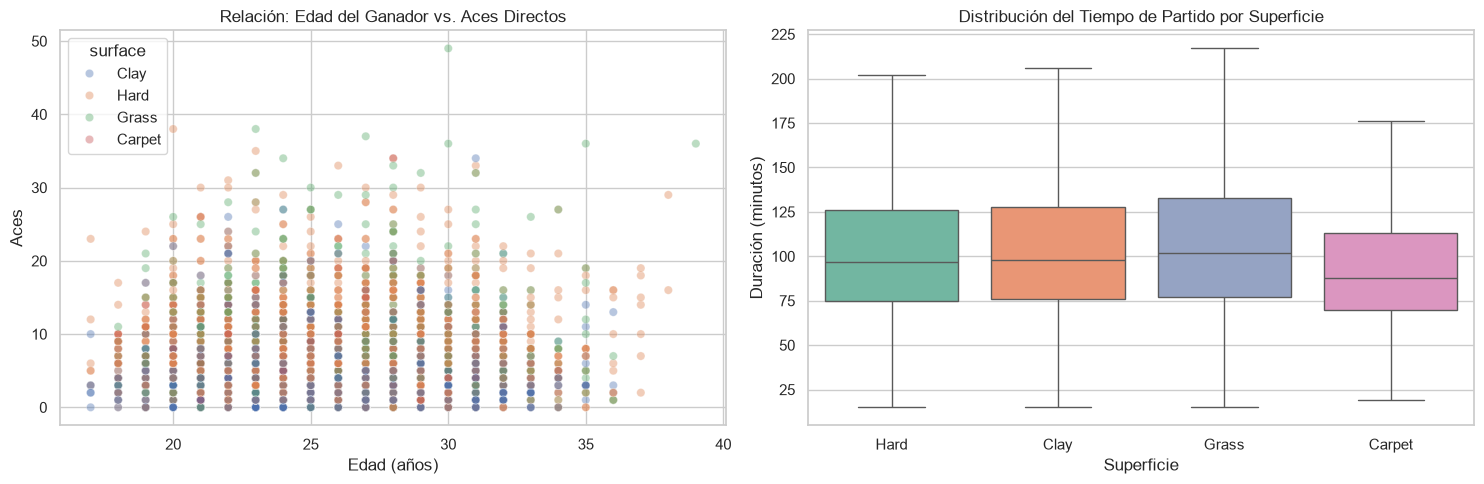

In [9]:
# Detectar automáticamente el nombre exacto de la columna de altura del ganador
col_ht = next((c for c in ['winner_ht', 'w_ht', 'ht', 'winner_height'] if c in df_clean.columns), None)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Altura vs Aces (o Edad vs Aces si no hubiera registro de altura)
if col_ht:
    sns.scatterplot(
        data=df_clean.sample(5000, random_state=42), 
        x=col_ht, 
        y='w_ace', 
        hue='surface', 
        alpha=0.4, 
        ax=axes[0]
    )
    axes[0].set_title(f'Relación: Altura del Ganador ({col_ht}) vs. Aces Directos')
    axes[0].set_xlabel('Altura (cm)')
else:
    sns.scatterplot(
        data=df_clean.sample(5000, random_state=42), 
        x='winner_age_calc', 
        y='w_ace', 
        hue='surface', 
        alpha=0.4, 
        ax=axes[0]
    )
    axes[0].set_title('Relación: Edad del Ganador vs. Aces Directos')
    axes[0].set_xlabel('Edad (años)')

axes[0].set_ylabel('Aces')

# Gráfico 2: Duración de partido por superficie
sns.boxplot(
    data=df_clean, 
    x='surface', 
    y='minutes', 
    palette='Set2', 
    showfliers=False, 
    ax=axes[1]
)
axes[1].set_title('Distribución del Tiempo de Partido por Superficie')
axes[1].set_xlabel('Superficie')
axes[1].set_ylabel('Duración (minutos)')

plt.tight_layout()
plt.show()

### 5.3. Matriz de Correlación de Métricas Técnicas
Se analiza el grado de asociación lineal (coeficiente de correlación de Pearson) entre las principales métricas de servicio, duración y edad:
* **minutes:** Duración total del encuentro.
* **w_ace / l_ace:** Número de saques directos de ganador y perdedor.
* **w_df / l_df:** Dobles faltas cometidas.
* **w_1st_pct:** Porcentaje de primeros servicios dentro.
* **w_1st_won_pct:** Efectividad de puntos convertidos con el primer servicio.
* **w_bp_saved_pct:** Porcentaje de bolas de break salvadas.
* **winner_age_calc / loser_age_calc:** Edades de los contendientes.

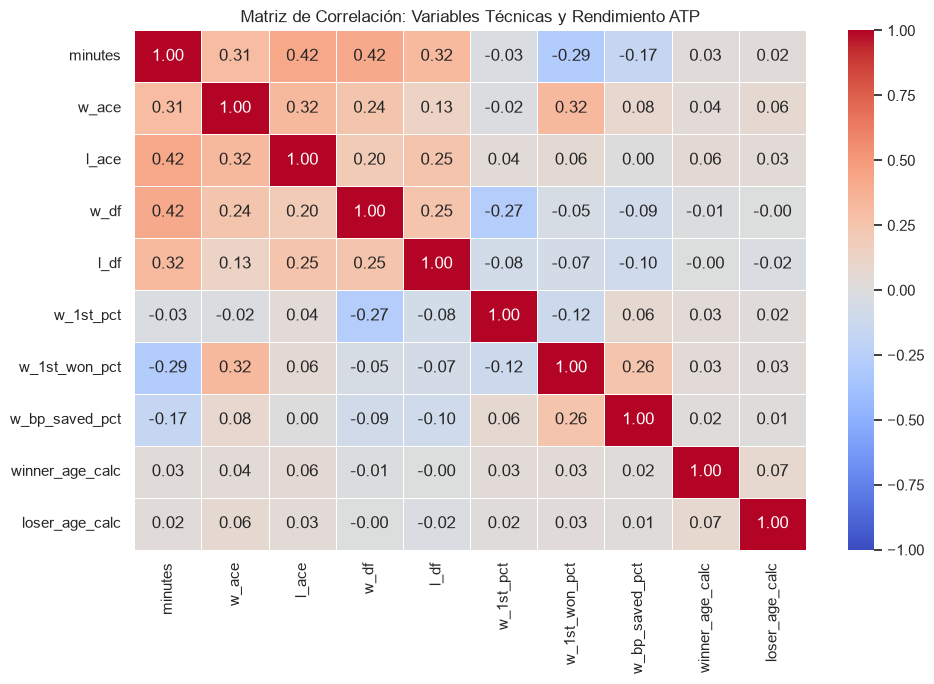

In [10]:
# 1. Selección de variables numéricas relevantes para correlación
cols_stats = [
    'minutes', 'w_ace', 'l_ace', 'w_df', 'l_df',
    'w_1st_pct', 'w_1st_won_pct', 'w_bp_saved_pct',
    'winner_age_calc', 'loser_age_calc'
]

# Filtrar solo columnas presentes en df_clean
cols_existentes = [c for c in cols_stats if c in df_clean.columns]
corr_matrix = df_clean[cols_existentes].corr()

# 2. Mapa de calor (Heatmap)
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title("Matriz de Correlación: Variables Técnicas y Rendimiento ATP")
plt.tight_layout()
plt.show()

### 5.4. Análisis de Lateralidad: Rendimiento de Zurdos vs. Diestros
Se analiza el porcentaje de victorias y efectividad técnica comparando jugadores diestros y zurdos:
* Distribución del volumen de victorias según la mano dominante (`winner_hand`).
* Tasa de victorias por mano según la superficie (Hard, Clay, Grass).
* Comparativa en la efectividad del primer servicio (`w_1st_pct` y `w_1st_won_pct`).

--- RENDIMIENTO SEGÚN MANO HÁBIL Y SUPERFICIE ---


total_victorias  media_aces  pct_primer_servicio  \
surface winner_hand                                                     
Carpet  Left                     124        7.66                62.25   
        Right                   1306        8.11                60.57   
Clay    Left                    2307        4.26                64.16   
        Right                  14825        4.73                61.57   
Grass   Left                     729       10.12                63.47   
        Right                   4826        9.64                62.62   
Hard    Left                    3283        7.02                62.46   
        Right                  24711        7.62                60.32   

                     pct_puntos_primer_servicio  
surface winner_hand                              
Carpet  Left                              78.90  
        Right                             79.54  
Clay    Left                              73.72  
        Right                             74.22  
Grass   Left                              79.41  
        Right                             79.11  
Hard    Left                              76.88  
        Right                             77.84

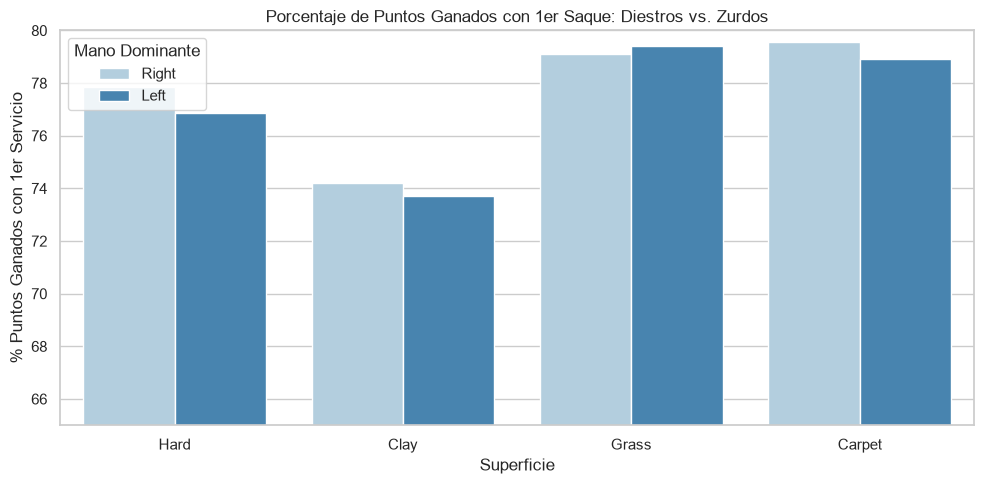

In [11]:
# 1. Filtrar jugadores con mano conocida (Right vs Left)
df_hands = df_clean[df_clean['winner_hand'].isin(['Right', 'Left'])].copy()

# 2. Agrupación por superficie y mano hábil del ganador
resumen_mano = df_hands.groupby(['surface', 'winner_hand']).agg(
    total_victorias=('tourney_name', 'count'),
    media_aces=('w_ace', 'mean'),
    pct_primer_servicio=('w_1st_pct', 'mean'),
    pct_puntos_primer_servicio=('w_1st_won_pct', 'mean')
).round(2)

print("--- RENDIMIENTO SEGÚN MANO HÁBIL Y SUPERFICIE ---")
display(resumen_mano)

# 3. Visualización comparativa
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_hands,
    x='surface',
    y='w_1st_won_pct',
    hue='winner_hand',
    palette='Blues',
    errorbar=None
)
plt.title('Porcentaje de Puntos Ganados con 1er Saque: Diestros vs. Zurdos')
plt.xlabel('Superficie')
plt.ylabel('% Puntos Ganados con 1er Servicio')
plt.legend(title='Mano Dominante')
plt.ylim(65, 80)
plt.tight_layout()
plt.show()

### 5.5. Análisis de Dominancia: Top 10 Jugadores de la Era Moderna (2000-2019)
Se identifican los tenistas con mayor número de victorias en el circuito profesional durante el periodo analizado:
* Conteo agregado de victorias por jugador (`winner_name_full`).
* Promedio de saques directos por partido y porcentaje medio de puntos ganados con el primer saque.
* Generación de un gráfico de barras horizontal representativo para el resumen ejecutivo.

--- TOP 10 JUGADORES CON MÁS VICTORIAS (2000-2019) ---


,winner_name_full,total_victorias,media_aces,pct_puntos_1er_saque,pais
0,Roger Federer,1092,7.898352,79.844342,SUI
1,Rafael Nadal,872,3.003440,74.885198,ESP
2,Novak Djokovic,775,5.512258,76.069398,SRB
3,David Ferrer,685,2.962044,73.365949,ESP
4,Andy Murray,607,7.000000,77.668045,GBR
5,Tomas Berdych,583,8.464837,81.190731,CZE
6,Andy Roddick,577,12.110919,82.184404,USA
7,Lleyton Hewitt,520,6.865385,77.625283,AUS
8,Fernando Verdasco,511,5.463796,75.166676,ESP
9,Tommy Robredo,507,4.224852,73.874057,ESP


C:\Users\salva\AppData\Local\Temp\ipykernel_17548\1154012753.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


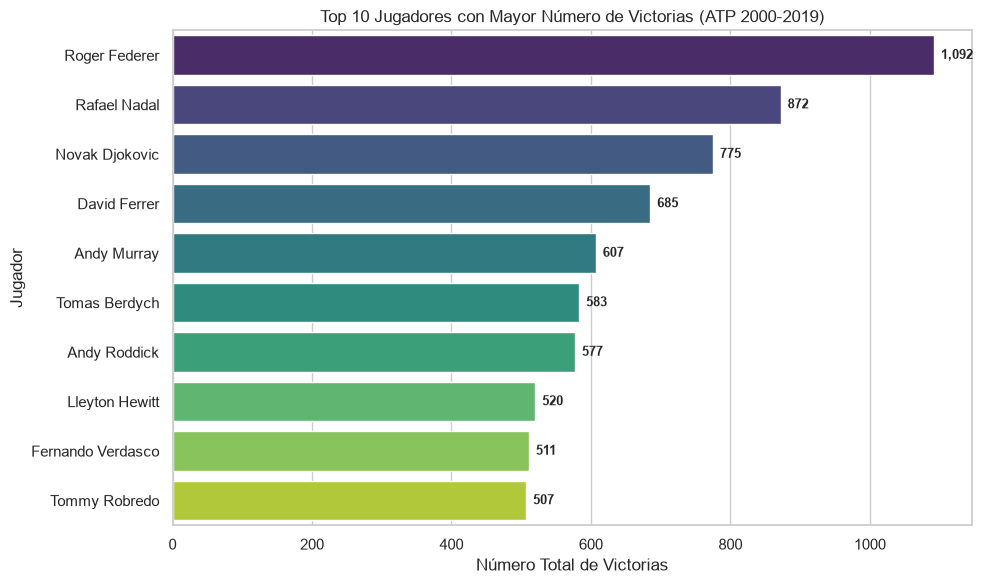

In [12]:
# 1. Agrupación y cálculo del Top 10 por victorias
top10_jugadores = df_clean.groupby('winner_name_full').agg(
    total_victorias=('tourney_name', 'count'),
    media_aces=('w_ace', 'mean'),
    pct_puntos_1er_saque=('w_1st_won_pct', 'mean'),
    pais=('winner_country', 'first')
).sort_values(by='total_victorias', ascending=False).head(10).reset_index()

print("--- TOP 10 JUGADORES CON MÁS VICTORIAS (2000-2019) ---")
display(top10_jugadores)

# 2. Visualización horizontal
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_jugadores,
    x='total_victorias',
    y='winner_name_full',
    palette='viridis'
)
plt.title('Top 10 Jugadores con Mayor Número de Victorias (ATP 2000-2019)')
plt.xlabel('Número Total de Victorias')
plt.ylabel('Jugador')

# Anotar valores numéricos en las barras
for idx, val in enumerate(top10_jugadores['total_victorias']):
    plt.text(val + 10, idx, f"{val:,}", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()